# Multi-Source Knowledge Router Agent Pattern
### Dynamic Classification, Targeted Fan-Out (`Send` API), and Multi-Agent Synthesis

This notebook implements the official LangChain tutorial [Router Knowledge Base](https://docs.langchain.com/oss/python/langchain/multi-agent/router-knowledge-base).

---

### Architectural Concept

```
                          ┌────────────────────────┐
                          │   User Query (Prompt)  │
                          └───────────┬────────────┘
                                      │
                                      ▼
                          ┌────────────────────────┐
                          │     Classify Node      │
                          │ (Router LLM Classifier)│
                          └───────────┬────────────┘
                                      │
               conditional edge returns [Send("github", ...), Send("notion", ...)]
                                      │
          ┌───────────────────────────┼───────────────────────────┐
          │ (if code/PRs relevant)    │ (if internal docs needed) │ (if discussions needed)
          ▼                           ▼                           ▼
┌──────────────────┐        ┌──────────────────┐        ┌──────────────────┐
│   GitHub Agent   │        │   Notion Agent   │        │   Slack Agent    │
│  (Code, Issues)  │        │ (Guides, Policies│        │(Threads, Chats)  │
└─────────┬────────┘        └─────────┬────────┘        └─────────┬────────┘
          │                           │                           │
          └───────────────────────────┼───────────────────────────┘
                                      │
                     State Reducer: Annotated[list, operator.add]
                                      │
                                      ▼
                          ┌────────────────────────┐
                          │    Synthesize Node     │
                          │(Coherent Unified Answer│
                          └───────────┬────────────┘
                                      │
                                      ▼
                          ┌────────────────────────┐
                          │     Combined Answer    │
                          └────────────────────────┘
```

### Why Use the Router Pattern?
1. **Intelligent Gating & Efficiency**: Instead of querying every database or loading 10+ tools into a single prompt, the router analyzes user intent upfront and calls **only** the relevant agents.
2. **Context Window Isolation**: Each specialist agent (`GitHub`, `Notion`, `Slack`) runs inside its own isolated scratchpad. Intermediate search logs never pollute the synthesizer's context.
3. **Optimized Sub-Questions**: The router doesn't just pass the raw user query; it crafts **targeted sub-questions** optimized for each source (e.g., asking GitHub for code implementations, and Slack for informal team decisions).
4. **Dynamic Parallel Fan-Out (`Send` API)**: LangGraph spawns only the required agent branches concurrently in a single superstep, aggregating outputs automatically via `operator.add`.


## 1. Setup & Environment Variables
We configure API credentials. We support both Google Gemini (`GOOGLE_API_KEY` / `GEMINI_API_KEY`) and OpenAI (`OPENAI_API_KEY`).


In [10]:
import os
from getpass import getpass
from dotenv import load_dotenv

# 1. Load environment variables from .env file if available
if os.path.exists(".env"):
    load_dotenv(dotenv_path=".env")
elif os.path.exists("../.env"):
    load_dotenv(dotenv_path="../.env")
else:
    load_dotenv()

# 2. Normalize Google Gemini key
if "GEMINI_API_KEY" not in os.environ and "GOOGLE_API_KEY" in os.environ:
    os.environ["GEMINI_API_KEY"] = os.environ["GOOGLE_API_KEY"]

print("✓ Environment configured successfully!")
print(f"Google API Key present: {'GEMINI_API_KEY' in os.environ or 'GOOGLE_API_KEY' in os.environ}")
print(f"OpenAI API Key present: {'OPENAI_API_KEY' in os.environ}")


✓ Environment configured successfully!
Google API Key present: True
OpenAI API Key present: False


## 2. State Definitions & The State Reducer (`operator.add`)

Understanding the state schema is the foundation of LangGraph:
- **`AgentInput`**: The minimal payload sent to each subagent: `{"query": str}`.
- **`AgentOutput`**: What each subagent returns: `{"source": str, "result": str}`.
- **`Classification`**: A routing decision containing the target source and the customized sub-question.
- **`RouterState`**: The overall graph state. Notice:
  ```python
  results: Annotated[list[AgentOutput], operator.add]
  ```
  The `Annotated[..., operator.add]` annotation is LangGraph's **State Reducer**. Whenever multiple parallel branches finish, LangGraph appends their output lists together rather than overwriting them!


In [11]:
import operator
from typing import Annotated, Literal, TypedDict
from pydantic import BaseModel, Field

# ==============================================================================
# State 1: Input payload passed to each individual specialist subagent
# ==============================================================================
class AgentInput(TypedDict):
    query: str  # The targeted sub-question crafted by the classifier for this agent


# ==============================================================================
# State 2: Output payload returned by each specialist subagent
# ==============================================================================
class AgentOutput(TypedDict):
    source: str  # Name of the knowledge base: 'github', 'notion', or 'slack'
    result: str  # The synthesized findings produced by that specific agent


# ==============================================================================
# State 3: Individual routing decision produced by the classifier
# ==============================================================================
class Classification(TypedDict):
    source: Literal["github", "notion", "slack"]  # Target specialist agent node
    query: str  # The optimized sub-question tailored specifically for that source


# ==============================================================================
# State 4: Overall Graph State for the Router System
# ==============================================================================
class RouterState(TypedDict):
    query: str                                          # Original user question
    classifications: list[Classification]               # Dynamic list of routes chosen by LLM
    results: Annotated[list[AgentOutput], operator.add] # REDUCER: Concatenates parallel outputs!
    final_answer: str                                   # Final combined response from Synthesizer


# ==============================================================================
# Pydantic Schema for Structured Output Classification
# ==============================================================================
class ClassificationResult(BaseModel):
    """Result of classifying a user query into agent-specific sub-questions."""
    classifications: list[Classification] = Field(
        description="List of knowledge base agents to invoke with their targeted sub-questions"
    )

print("✓ State definitions and Pydantic classification schema configured!")


✓ State definitions and Pydantic classification schema configured!


## 3. Knowledge Base Domain Tools
We define realistic domain tools for our three knowledge sources:
1. **GitHub Tools**: `search_code`, `search_issues`, `search_prs`
2. **Notion Tools**: `search_notion`, `get_page`
3. **Slack Tools**: `search_slack`, `get_thread`


In [12]:
from langchain.tools import tool

# ------------------------------------------------------------------------------
# Source A: GitHub Knowledge Base Tools (Code & Implementation Details)
# ------------------------------------------------------------------------------
@tool
def search_code(query: str, repo: str = "main") -> str:
    """Search code in GitHub repositories."""
    return f"Found code matching '{query}' in {repo}: authentication middleware in src/auth.py with JWT verification."

@tool
def search_issues(query: str) -> str:
    """Search GitHub issues and pull requests."""
    return f"Found 3 issues matching '{query}': #142 (API auth docs update), #89 (OAuth flow bugfix), #203 (token refresh expiration)."

@tool
def search_prs(query: str) -> str:
    """Search pull requests for implementation details."""
    return f"PR #156 added JWT authentication headers; PR #178 updated OAuth2 scopes to include 'read:reports'."


# ------------------------------------------------------------------------------
# Source B: Notion Knowledge Base Tools (Internal Documentation & Wikis)
# ------------------------------------------------------------------------------
@tool
def search_notion(query: str) -> str:
    """Search Notion workspace for documentation, guides, and policies."""
    return f"Found documentation: 'API Authentication Guide' - covers OAuth2 flow, API keys, and JWT tokens."

@tool
def get_page(page_id: str) -> str:
    """Get a specific Notion page by ID."""
    return f"Page content: Step-by-step authentication setup instructions: 1. Generate API Key in Developer Portal, 2. Attach Bearer token in Authorization header."


# ------------------------------------------------------------------------------
# Source C: Slack Knowledge Base Tools (Team Discussions & Informal Notes)
# ------------------------------------------------------------------------------
@tool
def search_slack(query: str) -> str:
    """Search Slack messages and threads for team discussions and informal context."""
    return f"Found discussion in #engineering: 'Use Bearer tokens for API auth; token TTL was reduced from 24h to 1h last sprint. See docs for refresh flow.'"

@tool
def get_thread(thread_id: str) -> str:
    """Get a specific Slack thread for detailed context."""
    return f"Thread discusses best practices for API key rotation and warns against hardcoding credentials in client-side code."

print("✓ All 7 domain tools registered across GitHub, Notion, and Slack!")


✓ All 7 domain tools registered across GitHub, Notion, and Slack!


## 4. Specialized Domain Subagents
Each knowledge base has its own dedicated agent initialized using LangChain's `create_agent`.
Notice the strict **separation of concerns**:
- The GitHub agent only sees GitHub tools.
- The Notion agent only sees Notion tools.
- The Slack agent only sees Slack tools.

This completely eliminates tool confusion and keeps prompts small and focused.


In [ ]:
from langchain.agents import create_agent
from langchain_google_genai import ChatGoogleGenerativeAI

# Configure models:
# We use gemini-2.5-flash for fast, deterministic reasoning across all agents
model = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", temperature=0)
router_llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", temperature=0)

# ==============================================================================
# Subagent 1: GitHub Specialist Agent
# ==============================================================================
github_agent = create_agent(
    model,
    tools=[search_code, search_issues, search_prs],
    system_prompt=(
        "You are a GitHub expert. Answer questions about code, "
        "API references, and implementation details by searching "
        "repositories, issues, and pull requests."
    ),
)

# ==============================================================================
# Subagent 2: Notion Specialist Agent
# ==============================================================================
notion_agent = create_agent(
    model,
    tools=[search_notion, get_page],
    system_prompt=(
        "You are a Notion expert. Answer questions about internal "
        "processes, policies, and team documentation by searching "
        "the organization's Notion workspace."
    ),
)

# ==============================================================================
# Subagent 3: Slack Specialist Agent
# ==============================================================================
slack_agent = create_agent(
    model,
    tools=[search_slack, get_thread],
    system_prompt=(
        "You are a Slack expert. Answer questions by searching "
        "relevant threads and discussions where team members have "
        "shared knowledge and solutions."
    ),
)

print("✓ GitHub, Notion, and Slack specialized subagents initialized successfully!")


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


✓ GitHub, Notion, and Slack specialized subagents initialized successfully!


## 5. Workflow Nodes & Dynamic Fan-Out (`Send` API)

Here are the 4 core steps of the Router workflow:
1. **`classify_query(state)`**:
   The classifier LLM analyzes the query and produces a list of relevant sources with tailored sub-queries using `.with_structured_output(ClassificationResult)`.
2. **`route_to_agents(state) -> list[Send]`**:
   This is the conditional edge function. It inspects the `classifications` list and dynamically returns:
   ```python
   [Send(c["source"], {"query": c["query"]}) for c in state["classifications"]]
   ```
   **Why `Send` is revolutionary**: If only GitHub is relevant, only 1 branch runs. If all 3 are relevant, all 3 run in parallel!
3. **Agent Nodes (`query_github`, `query_notion`, `query_slack`)**:
   Invokes the subagent and returns `{"results": [{"source": ..., "result": ...}]}`. LangGraph's `operator.add` reducer automatically appends them!
4. **`synthesize_results(state)`**:
   Synthesizes the gathered findings into a unified, non-redundant markdown answer.


In [14]:
from langgraph.types import Send

# ==============================================================================
# Node 1: Classify Node (Determines relevant sources and targeted sub-questions)
# ==============================================================================
def classify_query(state: RouterState) -> dict:
    """Classify query and determine which agents to invoke with tailored sub-questions."""
    structured_llm = router_llm.with_structured_output(ClassificationResult)

    result = structured_llm.invoke([
        {
            "role": "system",
            "content": """Analyze this query and determine which knowledge bases to consult.
For each relevant source, generate a targeted sub-question optimized for that source.

Available sources:
- github: Code, API references, implementation details, issues, pull requests
- notion: Internal documentation, processes, policies, team wikis
- slack: Team discussions, informal knowledge sharing, recent conversations

Return ONLY the sources that are relevant to the query."""
        },
        {"role": "user", "content": state["query"]}
    ])

    return {"classifications": result.classifications}


# ==============================================================================
# Conditional Edge: Dynamic Fan-Out via Send() API
# ==============================================================================
def route_to_agents(state: RouterState) -> list[Send]:
    """Fan out dynamically to only the selected agents based on classifications."""
    return [
        Send(c["source"], {"query": c["query"]})
        for c in state["classifications"]
    ]


# ==============================================================================
# Node 2A: GitHub Agent Execution Node
# ==============================================================================
def query_github(state: AgentInput) -> dict:
    """Query the GitHub agent with the targeted sub-question."""
    print(f"  ⚡ [Routing] Executing GitHub Agent for: '{state['query']}'")
    result = github_agent.invoke({
        "messages": [{"role": "user", "content": state["query"]}]
    })
    return {"results": [{"source": "github", "result": result["messages"][-1].content}]}


# ==============================================================================
# Node 2B: Notion Agent Execution Node
# ==============================================================================
def query_notion(state: AgentInput) -> dict:
    """Query the Notion agent with the targeted sub-question."""
    print(f"  ⚡ [Routing] Executing Notion Agent for: '{state['query']}'")
    result = notion_agent.invoke({
        "messages": [{"role": "user", "content": state["query"]}]
    })
    return {"results": [{"source": "notion", "result": result["messages"][-1].content}]}


# ==============================================================================
# Node 2C: Slack Agent Execution Node
# ==============================================================================
def query_slack(state: AgentInput) -> dict:
    """Query the Slack agent with the targeted sub-question."""
    print(f"  ⚡ [Routing] Executing Slack Agent for: '{state['query']}'")
    result = slack_agent.invoke({
        "messages": [{"role": "user", "content": state["query"]}]
    })
    return {"results": [{"source": "slack", "result": result["messages"][-1].content}]}


# ==============================================================================
# Node 3: Synthesizer Node (Combines parallel results into a cohesive answer)
# ==============================================================================
def synthesize_results(state: RouterState) -> dict:
    """Combine results from all gathered agents into a coherent answer."""
    if not state.get("results"):
        return {"final_answer": "No results found from any knowledge source."}

    formatted = [
        f"**From {r['source'].title()}:**\n{r['result']}"
        for r in state["results"]
    ]

    synthesis_response = router_llm.invoke([
        {
            "role": "system",
            "content": f"""Synthesize these search results to answer the original question: "{state['query']}"

- Combine information from multiple sources without redundancy
- Highlight the most relevant and actionable information
- Note any discrepancies between sources
- Keep the response concise and well-organized"""
        },
        {"role": "user", "content": "\n\n".join(formatted)}
    ])

    return {"final_answer": synthesis_response.content}

print("✓ All workflow nodes and Send() dynamic router functions defined!")


✓ All workflow nodes and Send() dynamic router functions defined!


## 6. Build & Compile the StateGraph
We wire the graph:
- `START -> classify`
- `classify -> route_to_agents` conditional edge that can route to `["github", "notion", "slack"]`
- All three agent nodes fan back in to `synthesize`
- `synthesize -> END`


✓ Router Knowledge Base StateGraph compiled successfully!


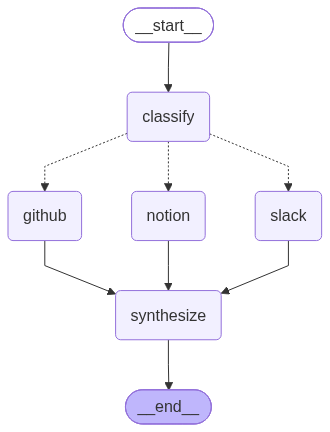

In [15]:
from langgraph.graph import StateGraph, START, END

# Initialize StateGraph with our RouterState schema
builder = StateGraph(RouterState)

# 1. Add all functional nodes
builder.add_node("classify", classify_query)
builder.add_node("github", query_github)
builder.add_node("notion", query_notion)
builder.add_node("slack", query_slack)
builder.add_node("synthesize", synthesize_results)

# 2. Add edges:
# Entry edge: START -> classify
builder.add_edge(START, "classify")

# Conditional routing edge from classify using Send()
builder.add_conditional_edges(
    "classify",
    route_to_agents,
    ["github", "notion", "slack"]
)

# Fan-in edges: All branches merge into synthesize
builder.add_edge("github", "synthesize")
builder.add_edge("notion", "synthesize")
builder.add_edge("slack", "synthesize")

# Exit edge: synthesize -> END
builder.add_edge("synthesize", END)

# Compile the graph
workflow = builder.compile()

print("✓ Router Knowledge Base StateGraph compiled successfully!")
workflow


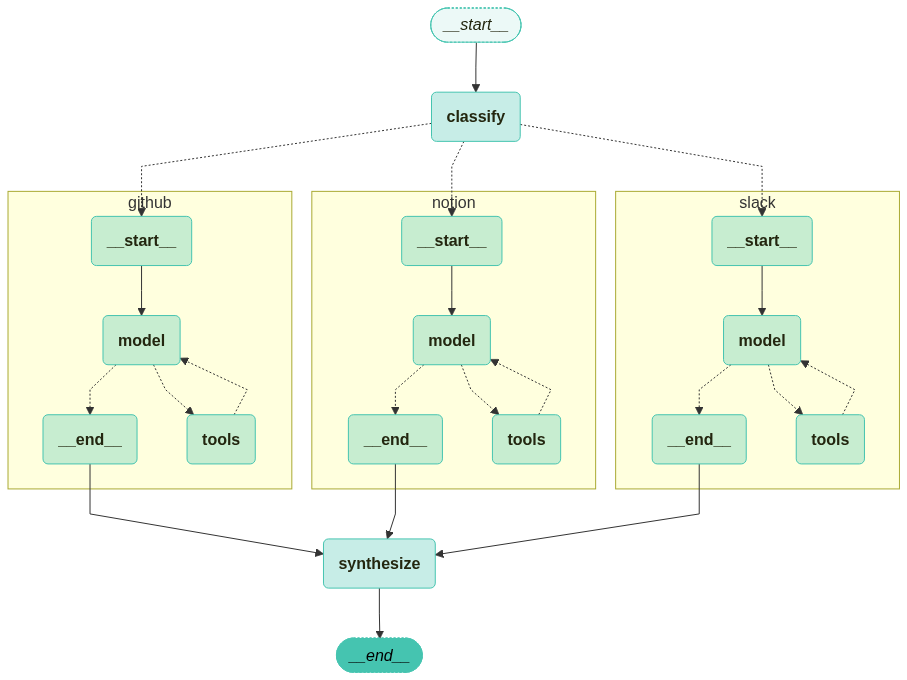

In [16]:
from langchain_opentutorial.graphs import visualize_graph
visualize_graph(workflow, xray=True)

## 7. Execution Run: Multi-Scenario Testing

To thoroughly test our router pattern, we run three different test scenarios:
1. **Scenario 1: Broad Cross-Cutting Query** (*"How do I authenticate API requests?"*)
   - *Expected Routing*: Touches all 3 sources (GitHub for code, Notion for docs, Slack for team discussions).
2. **Scenario 2: Code Implementation Query** (*"Where in the codebase is JWT verification implemented and what PR added it?"*)
   - *Expected Routing*: Touches **GitHub only**. Notion and Slack are skipped, saving tokens and latency!
3. **Scenario 3: Policy & Discussion Query** (*"What is our policy on API key rotation and where was it discussed?"*)
   - *Expected Routing*: Touches **Notion and Slack only**. GitHub is safely skipped!


In [17]:
def run_test_query(query: str, test_title: str):
    print("\n" + "=" * 80)
    print(f"🎯 {test_title}")
    print(f"Question: '{query}'")
    print("=" * 80)
    
    result = workflow.invoke({
        "query": query,
        "classifications": [],
        "results": [],
        "final_answer": ""
    })
    
    print("\n📍 Router Classifications (Dynamic Decisions):")
    for c in result["classifications"]:
        print(f"  👉 Source: [{c['source'].upper()}] | Sub-Question: '{c['query']}'")
        
    print(f"\n📊 Total Knowledge Sources Consulted: {len(result['results'])}")
    for r in result["results"]:
        print(f"  • {r['source'].title()}: {len(r['result'])} characters of findings")
        
    print("\n✨ Final Synthesized Answer:")
    print("-" * 60)
    print(result["final_answer"])
    print("-" * 60)
    return result

# ------------------------------------------------------------------------------
# Test 1: Cross-Cutting Query (Expected: GitHub + Notion + Slack)
# ------------------------------------------------------------------------------
res1 = run_test_query(
    "How do I authenticate API requests?",
    "SCENARIO 1: Cross-Cutting Query (All 3 Sources)"
)



🎯 SCENARIO 1: Cross-Cutting Query (All 3 Sources)
Question: 'How do I authenticate API requests?'
  ⚡ [Routing] Executing GitHub Agent for: 'API authentication methods, examples, and documentation'  ⚡ [Routing] Executing Notion Agent for: 'Internal API authentication guidelines, policies, and setup instructions'


📍 Router Classifications (Dynamic Decisions):
  👉 Source: [GITHUB] | Sub-Question: 'API authentication methods, examples, and documentation'
  👉 Source: [NOTION] | Sub-Question: 'Internal API authentication guidelines, policies, and setup instructions'

📊 Total Knowledge Sources Consulted: 2
  • Github: 1 characters of findings
  • Notion: 1 characters of findings

✨ Final Synthesized Answer:
------------------------------------------------------------
To authenticate API requests, several common methods are used, and the most suitable approach often depends on the specific API you are interacting with.

Here are the primary methods:

1.  **OAuth / OAuth2:** This is a widely

In [18]:
# ------------------------------------------------------------------------------
# Test 2: Code Implementation Query (Expected: GitHub ONLY)
# ------------------------------------------------------------------------------
res2 = run_test_query(
    "Where in the codebase is JWT verification implemented and what PR added it?",
    "SCENARIO 2: Implementation Query (GitHub Only)"
)

# ------------------------------------------------------------------------------
# Test 3: Policy & Discussion Query (Expected: Notion + Slack ONLY)
# ------------------------------------------------------------------------------
res3 = run_test_query(
    "What is our policy on API key rotation and where was it discussed by the team?",
    "SCENARIO 3: Policy & Discussion Query (Notion + Slack)"
)



🎯 SCENARIO 2: Implementation Query (GitHub Only)
Question: 'Where in the codebase is JWT verification implemented and what PR added it?'
  ⚡ [Routing] Executing GitHub Agent for: 'JWT verification implementation location and the pull request that introduced it'

📍 Router Classifications (Dynamic Decisions):
  👉 Source: [GITHUB] | Sub-Question: 'JWT verification implementation location and the pull request that introduced it'

📊 Total Knowledge Sources Consulted: 1
  • Github: 1 characters of findings

✨ Final Synthesized Answer:
------------------------------------------------------------
JWT verification is implemented in `src/auth.py` within the authentication middleware.

It was added by Pull Request **#156**, which introduced JWT authentication headers.
------------------------------------------------------------

🎯 SCENARIO 3: Policy & Discussion Query (Notion + Slack)
Question: 'What is our policy on API key rotation and where was it discussed by the team?'
  ⚡ [Routing] Executi